# Week 1 — Dataset Exploration

Digital Image Processing mini project: Driver Drowsiness Detection.
Amey Pawar (23108B0057), Sejal Andhale (23108B0049).

Loads the curated 40-image sample manifest (`data/samples/manifest.csv`),
summarizes class balance and stratification (glasses / lighting /
reflections / sensor), inspects raw image dimensions (motivating the
Week-2 normalization step), compares mean pixel intensity between the
`alert` and `drowsy` classes, and displays the Week-1 contact sheet.

No preprocessing or modeling happens here — this notebook is purely
descriptive, Week-1 dataset exploration.


In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.dataset import load_manifest
from src.viz import contact_sheet

MANIFEST_PATH = REPO_ROOT / "data" / "samples" / "manifest.csv"
samples = load_manifest(MANIFEST_PATH)
print(f"Loaded {len(samples)} samples from {MANIFEST_PATH}")


Matplotlib is building the font cache; this may take a moment.


Loaded 40 samples from /Users/amey/Projects/clg/dip-mini-project-drowsiness/data/samples/manifest.csv


## Per-class counts

`alert` = eyeState 1 (open), `drowsy` = eyeState 0 (closed).

In [2]:
def class_of(sample):
    return "alert" if sample.is_open else "drowsy"

class_counts = Counter(class_of(s) for s in samples)
print(class_counts)


Counter({'alert': 20, 'drowsy': 20})


## Stratification: glasses / lighting / reflections / sensor

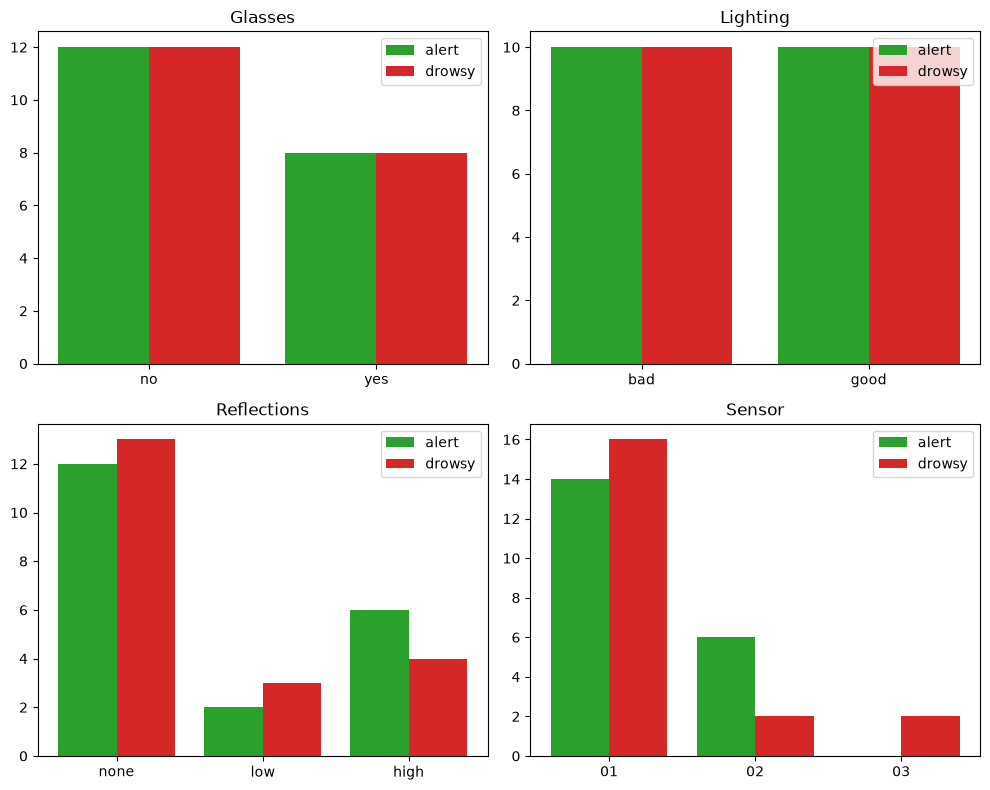

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

def bar_by(ax, attr, labels, title):
    xs = list(labels.keys())
    for cls, color, offset in (("alert", "tab:green", -0.2), ("drowsy", "tab:red", 0.2)):
        subset = [s for s in samples if class_of(s) == cls]
        counter = Counter(getattr(s, attr) for s in subset)
        heights = [counter.get(k, 0) for k in xs]
        ax.bar([i + offset for i in range(len(xs))], heights, width=0.4, label=cls, color=color)
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels(list(labels.values()))
    ax.set_title(title)
    ax.legend()

bar_by(axes[0, 0], "glasses", {0: "no", 1: "yes"}, "Glasses")
bar_by(axes[0, 1], "lighting", {0: "bad", 1: "good"}, "Lighting")
bar_by(axes[1, 0], "reflections", {0: "none", 1: "low", 2: "high"}, "Reflections")
bar_by(axes[1, 1], "sensor", {"01": "01", "02": "02", "03": "03"}, "Sensor")
plt.tight_layout()
plt.show()


## Image dimensions

MRL Eye Dataset images are variable-size. This distribution motivates the Week-2 preprocessing step (resizing/normalizing all images to a common shape).

31 distinct (width, height) pairs among 40 images


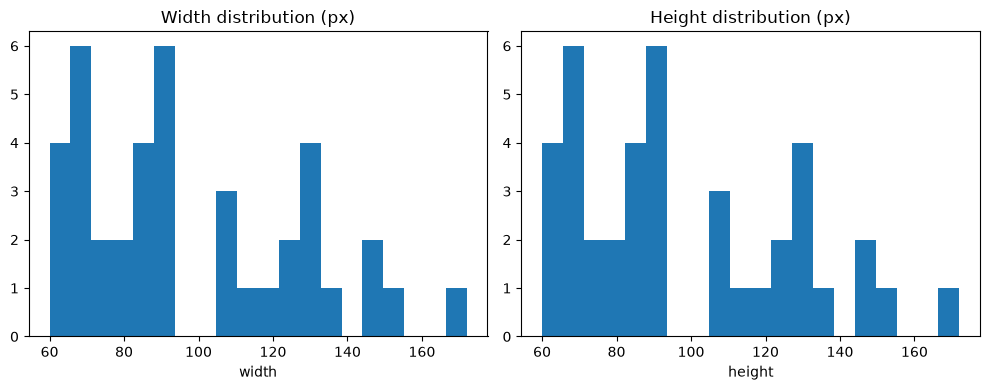

In [4]:
dims = [Image.open(s.path).size for s in samples]
widths = [w for w, h in dims]
heights = [h for w, h in dims]
print(f"{len(set(dims))} distinct (width, height) pairs among {len(samples)} images")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(widths, bins=20)
axes[0].set_title("Width distribution (px)")
axes[0].set_xlabel("width")
axes[1].hist(heights, bins=20)
axes[1].set_title("Height distribution (px)")
axes[1].set_xlabel("height")
plt.tight_layout()
plt.show()


## Mean pixel intensity: alert vs drowsy

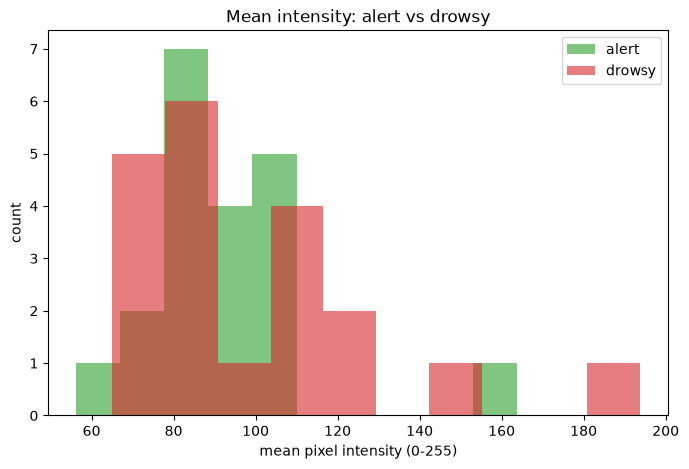

In [5]:
def mean_intensity(sample):
    img = Image.open(sample.path).convert("L")
    return float(np.asarray(img, dtype=np.float64).mean())

alert_intensities = [mean_intensity(s) for s in samples if class_of(s) == "alert"]
drowsy_intensities = [mean_intensity(s) for s in samples if class_of(s) == "drowsy"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(alert_intensities, bins=10, alpha=0.6, label="alert", color="tab:green")
ax.hist(drowsy_intensities, bins=10, alpha=0.6, label="drowsy", color="tab:red")
ax.set_xlabel("mean pixel intensity (0-255)")
ax.set_ylabel("count")
ax.set_title("Mean intensity: alert vs drowsy")
ax.legend()
plt.show()


## Contact sheet

8x5 grid, green border = alert (open), red border = drowsy (closed). Regenerates `results/week1_sample_grid.png`.

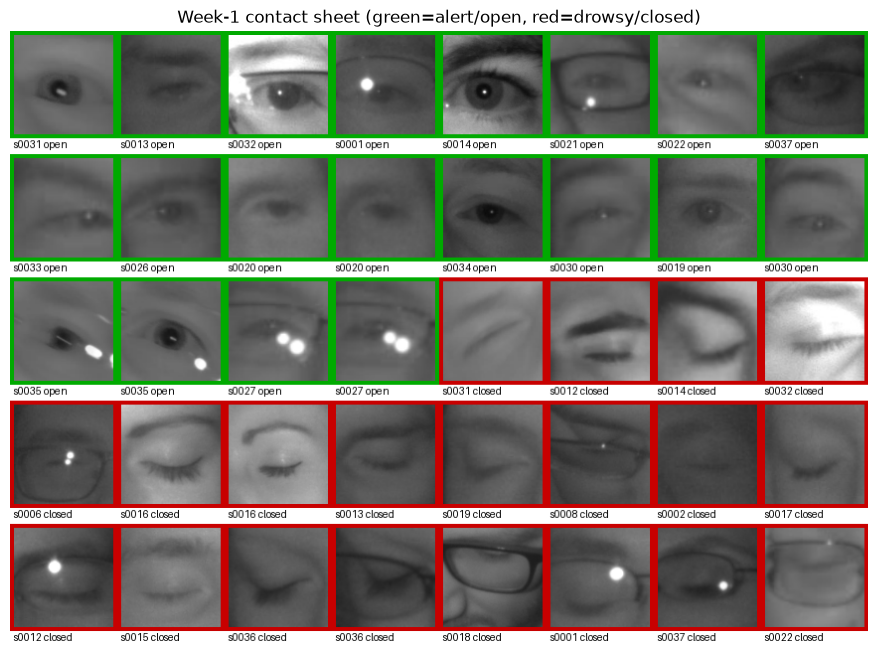

Saved /Users/amey/Projects/clg/dip-mini-project-drowsiness/results/week1_sample_grid.png


In [6]:
sheet = contact_sheet(samples, cols=8, tile=(100, 100))

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(sheet)
ax.axis("off")
ax.set_title("Week-1 contact sheet (green=alert/open, red=drowsy/closed)")
plt.show()

RESULTS_PATH = REPO_ROOT / "results" / "week1_sample_grid.png"
sheet.save(RESULTS_PATH)
print(f"Saved {RESULTS_PATH}")
